In [77]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import special
from scipy.special import comb
from scipy.stats import norm
from statsmodels.distributions.empirical_distribution import ECDF

In [78]:
nums = np.array(np.random.exponential(size=25))

In [79]:
nums

array([4.33147013e-01, 2.19596749e+00, 3.08908432e-01, 6.59186379e-01,
       1.32350263e-01, 4.07909997e-01, 4.60055880e-03, 5.03817236e-01,
       1.46989637e+00, 1.21452208e+00, 1.30479348e-02, 6.41872011e-01,
       5.10627971e-01, 3.05257595e-01, 5.53831078e+00, 1.70043839e-01,
       2.02209991e+00, 9.03702895e-01, 4.16860375e-01, 1.39814509e+00,
       1.31329474e+00, 2.59626700e+00, 2.13782100e+00, 4.80009538e-01,
       8.98573607e-01])

a) Определить моду, медиану, размах, оценку коэффициента асимметрии

In [80]:
print(f"Мода: вся выборка")
print(f"Медиана: {np.median(nums)}")
print(f"Размах: {max(nums)-min(nums)}")
print(f"Коэффициент асимметрии: {scipy.stats.skew(nums)}")

Мода: вся выборка
Медиана: 0.6418720112353931
Размах: 5.5337102175374895
Коэффициент асимметрии: 2.3057888044620443


b) Построить эмпирическую функциу распределения, гистограмму, boxplot

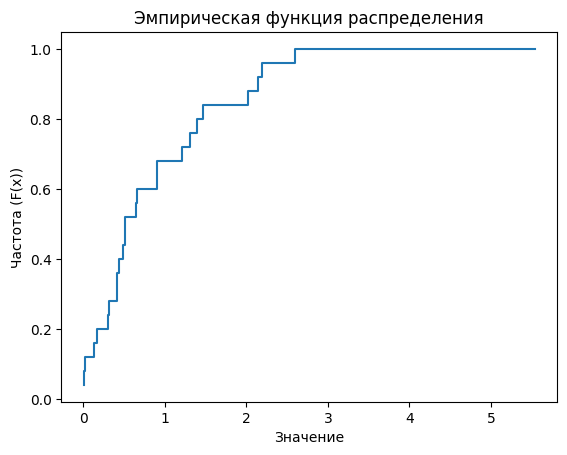

In [81]:
ecdf = ECDF(nums)

plt.step(ecdf.x, ecdf.y, label='ECDF')
plt.xlabel('Значение')
plt.ylabel('Частота (F(x))')
plt.title('Эмпирическая функция распределения')
plt.show()

(array([0.69392864, 0.17348216, 0.17348216, 0.        , 0.        ,
        0.04337054]),
 array([4.60055880e-03, 9.26885595e-01, 1.84917063e+00, 2.77145567e+00,
        3.69374070e+00, 4.61602574e+00, 5.53831078e+00]),
 <BarContainer object of 6 artists>)

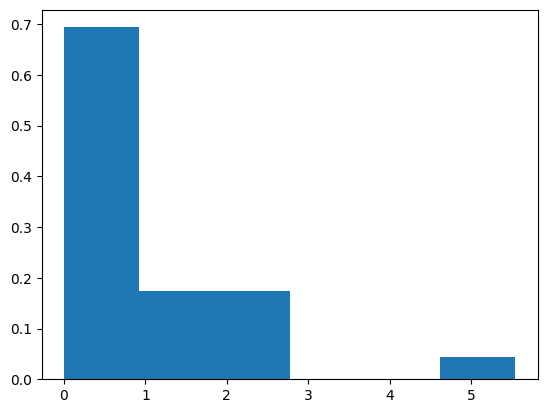

In [82]:
plt.hist(nums, bins='sturges', density=True)

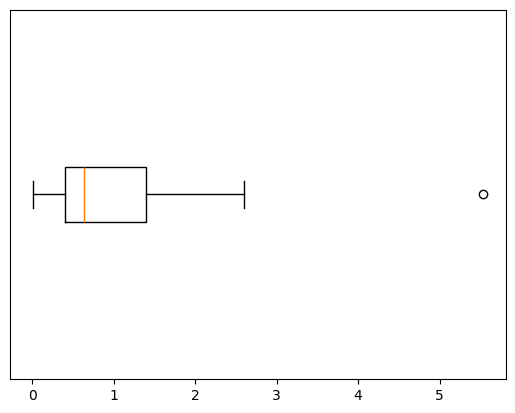

In [83]:
plt.boxplot(nums, vert=False)
plt.yticks([])
plt.show()

c) Сравнить оценку плотности распределения среднего арифметического элементов выборки, полученную с помощью ЦПТ и bootstrap

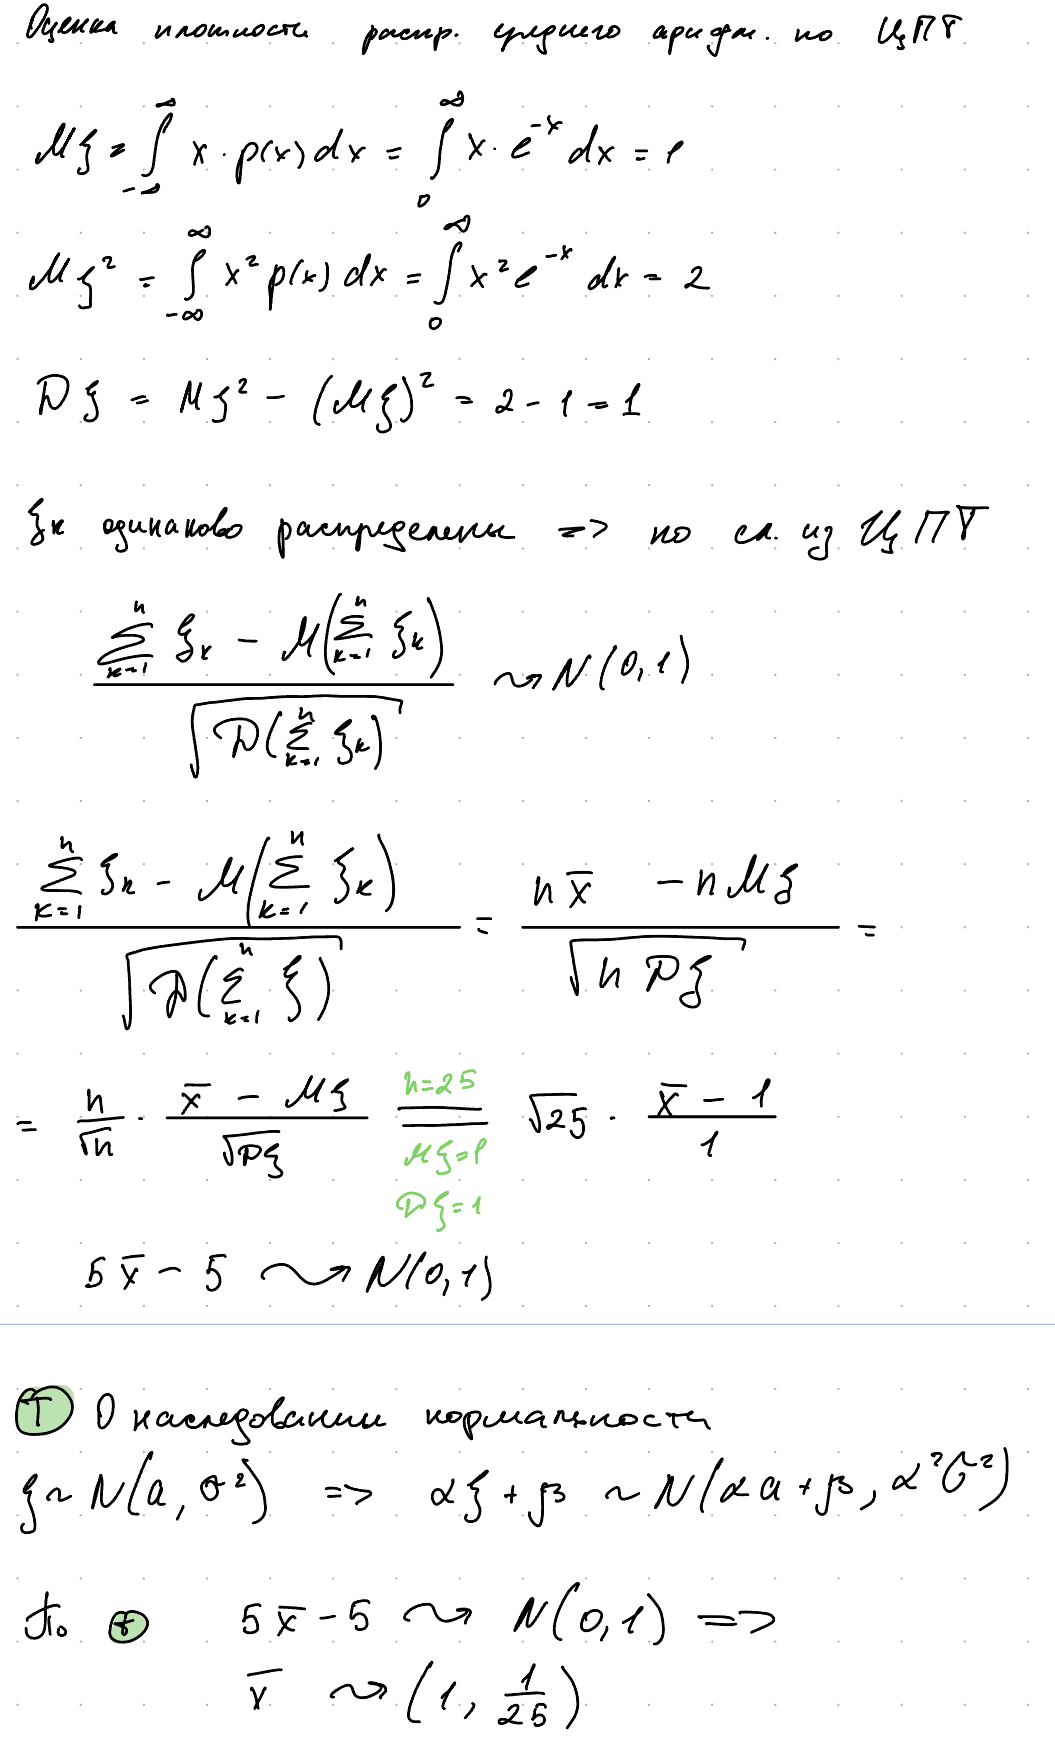

In [84]:
def bootstrap_stat(arr, stat_func, B=1000, seed=25):
    rng = np.random.default_rng(seed)
    n = len(arr)
    stats = np.empty(B)
    for b in range(B):
        sample = rng.choice(arr, size=n, replace=True)
        stats[b] = stat_func(sample)
    return stats

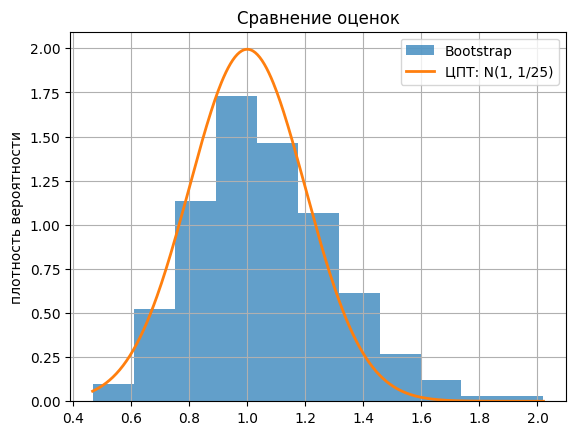

In [85]:
boot_means = bootstrap_stat(nums, np.mean, B=1000, seed=25)

a = 1
sigma = 1/5

t = np.linspace(min(boot_means), max(boot_means), 400)

plt.figure()
plt.hist(boot_means, bins="sturges", density=True, alpha=0.7, label="Bootstrap")

plt.plot(t, norm.pdf(t, loc=a, scale=sigma), linewidth=2, label="ЦПТ: N(1, 1/25)")

plt.ylabel("плотность вероятности")
plt.title("Сравнение оценок")
plt.legend()
plt.grid(True)
plt.show()

d) Найти бутстраповскую оценку плотности распределения коэффициента асимметрии

Оценить вероятность того, что коэффициент асимметрии будет меньше 1

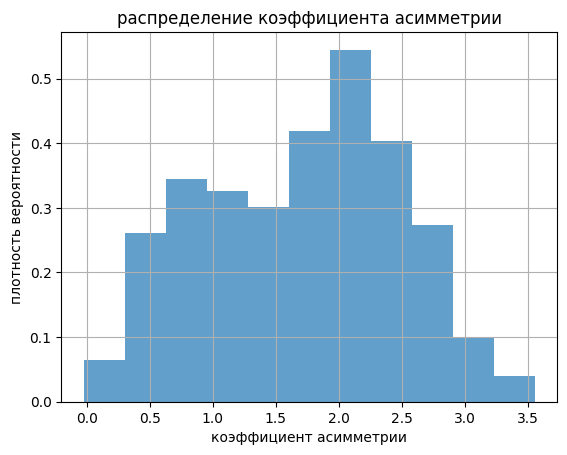

P(коэффициент ассиметрии < 1) ≈ 0.237


In [86]:
boot_skew = bootstrap_stat(nums, scipy.stats.skew, B=1000, seed=25)

plt.figure()
plt.hist(boot_skew, bins="sturges", density=True, alpha=0.7)
plt.xlabel("коэффициент асимметрии")
plt.ylabel("плотность вероятности")
plt.title("распределение коэффициента асимметрии")
plt.grid(True)
plt.show()

prob = np.mean(boot_skew < 1)
print("P(коэффициент ассиметрии < 1) ≈", prob)

e) Сравнить плотность распределения медианы выборки с будстраповской оценкой этой плотности

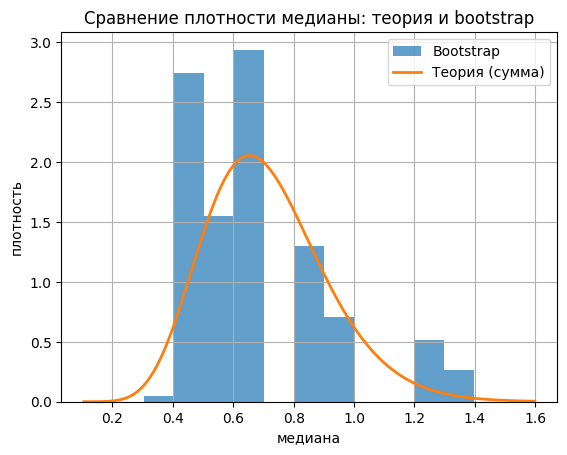

In [87]:
N = 25
k = N // 2 + 1  # 13

def kappa(x):
    x = np.asarray(x, dtype=float)

    coef = N * comb(N - 1, k - 1)
    a = N - k + 1
    j = np.arange(0, k)
    y = coef * np.sum(comb(k - 1, j) * ((-1.0) ** j) * np.exp(-(a + j) * x[..., None]), axis=-1)

    return np.where(x >= 0, y, 0.0)



boot_medians = bootstrap_stat(nums, np.median, B=1000, seed=25)

x_min = max(0.0, np.min(boot_medians) - 0.2)
x_max = np.max(boot_medians) + 0.2
x_grid = np.linspace(x_min, x_max, 500)

plt.figure()
plt.hist(boot_medians, bins="sturges", density=True, alpha=0.7, label="Bootstrap")
plt.plot(x_grid, kappa(x_grid), linewidth=2, label="Теория (сумма)")
plt.xlabel("медиана")
plt.ylabel("плотность")
plt.title("Сравнение плотности медианы: теория и bootstrap")
plt.grid(True)
plt.legend()
plt.show()